In [ ]:
from google.colab import files
import pandas as pd


Pada tahap awal, dilakukan proses import library yang dibutuhkan untuk mendukung pengolahan data.

Library `pandas` digunakan untuk membaca dan mengelola dataset dalam bentuk tabel (DataFrame), sehingga memudahkan proses manipulasi dan analisis data.

Selain itu, modul `files` dari Google Colab digunakan untuk mengunggah dataset secara langsung dari perangkat lokal ke dalam lingkungan kerja.

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print(f"File berhasil dimuat: {file_name}")
df.head()

Saving scrapped_Shopee 12.12_ID_.csv to scrapped_Shopee 12.12_ID_.csv
File berhasil dimuat: scrapped_Shopee 12.12_ID_.csv


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,a4a2655a-bf93-4d97-be4d-51455cf43e19,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"penipuan berkedok Flash sale,ga ada mati nya,I...",1,0,3.38.35,2024-12-12 16:37:40,NaN,NaN,3.38.35
1,108847f4-8c20-4535-b165-c07e3ebc673b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"lama kali kurir nya , kalo bisa min... , tamba...",4,0,3.38.35,2024-12-12 11:30:25,"Hi kak makasih bintangnya, maaf udh bikin ga n...",2024-12-12 12:30:37,3.38.35
2,137292a6-a210-4ba5-859b-9b3b6b4a557e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"BPK ibu shopee emang keren,cuman sayang,ongkir...",5,0,3.38.35,2024-12-12 10:20:09,"Hai kak, mohon maaf atas ketidaknyamanan nya. ...",2024-11-18 13:13:40,3.38.35
3,b57d7e7a-1e3d-43e0-98b3-b8ff828f5207,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Maaf kk, semua pakai SPX, tidak ada pilihan yg...",4,0,3.38.35,2024-12-12 08:58:53,"Hai kak Effi Hidayaningsih,maaf atas ketidakny...",2024-12-11 10:51:15,3.38.35
4,69e6a85c-77b6-4d55-be52-2dabc8ff9d26,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Tetap bertahan meski gampang eror aplikasinya ...,5,0,3.38.35,2024-12-12 05:07:57,NaN,NaN,3.38.35


## Proses Upload dan Pembacaan Dataset

Pada tahap ini dilakukan proses pengunggahan dataset dari perangkat lokal ke dalam Google Colab menggunakan fungsi `files.upload()`.

File yang telah diunggah kemudian diidentifikasi melalui nama file yang tersimpan dalam objek `uploaded`. Karena diasumsikan hanya satu file yang diunggah, maka file pertama langsung diambil untuk diproses lebih lanjut.

Dataset kemudian dibaca menggunakan fungsi `pandas.read_csv()` dan disimpan ke dalam variabel `df` dalam bentuk DataFrame. Struktur ini memungkinkan data untuk diolah secara efisien pada tahap berikutnya.

Sebagai validasi awal, ditampilkan nama file yang berhasil dimuat untuk memastikan bahwa proses upload dan pembacaan data berjalan dengan baik.

In [ ]:
df.shape

(85500, 11)

## Mengetahui Dimensi Dataset

Pada tahap ini dilakukan pengecekan dimensi dataset menggunakan atribut `df.shape`.

Fungsi ini digunakan untuk mengetahui jumlah baris (data) dan kolom (fitur) yang terdapat dalam dataset. Informasi ini penting untuk memahami skala data yang akan diolah, serta sebagai dasar dalam menentukan strategi preprocessing dan pemodelan.

Jumlah baris menunjukkan banyaknya data ulasan yang akan dianalisis, sedangkan jumlah kolom menunjukkan jumlah atribut atau fitur yang tersedia dalam dataset.

In [ ]:
df.columns

Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'appVersion'],
      dtype='object')

## Menampilkan Nama Kolom Dataset

Pada tahap ini dilakukan pengecekan nama-nama kolom yang terdapat dalam dataset menggunakan atribut `df.columns`.

Langkah ini bertujuan untuk mengetahui struktur atribut yang tersedia, sehingga dapat menentukan kolom mana yang relevan untuk digunakan dalam proses analisis sentimen.

Dalam proyek ini, kolom yang menjadi fokus utama adalah kolom yang berisi teks ulasan (misalnya `content`) dan skor atau rating (misalnya `score`), yang nantinya akan digunakan untuk proses pelabelan sentimen.

In [ ]:
df = df[['content', 'score']]

## Seleksi Kolom yang Relevan

Pada tahap ini dilakukan pemilihan kolom yang relevan untuk proses analisis sentimen, yaitu kolom `content` sebagai data teks ulasan dan kolom `score` sebagai nilai rating.

Pemilihan ini bertujuan untuk menyederhanakan dataset dengan hanya mempertahankan fitur yang действительно dibutuhkan, sehingga proses pengolahan data menjadi lebih efisien dan terarah.

Kolom `content` akan digunakan sebagai input utama dalam proses analisis teks, sedangkan kolom `score` akan digunakan untuk membuat label sentimen (positif, netral, negatif) pada tahap selanjutnya.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85500 entries, 0 to 85499
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  85499 non-null  object
 1   score    85500 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


## Informasi Struktur Dataset

Pada tahap ini dilakukan pengecekan struktur dataset menggunakan fungsi `df.info()`.

Fungsi ini digunakan untuk menampilkan informasi umum mengenai dataset, seperti jumlah data, nama kolom, tipe data (data type), serta jumlah nilai non-null pada setiap kolom.

Informasi ini penting untuk memastikan bahwa setiap kolom memiliki tipe data yang sesuai dan untuk mendeteksi adanya data yang hilang (missing values) sebelum masuk ke tahap preprocessing.

Dengan mengetahui struktur dataset sejak awal, potensi kesalahan dalam proses pengolahan data dapat diminimalkan.

In [ ]:
df = df.dropna(subset=['content'])

## Penanganan Missing Value pada Kolom Teks

Pada tahap ini dilakukan penghapusan data yang memiliki nilai kosong (missing value) pada kolom `content` menggunakan fungsi `dropna()`.

Kolom `content` merupakan fitur utama dalam analisis sentimen karena berisi teks ulasan yang akan diproses lebih lanjut. Data yang tidak memiliki isi teks tidak dapat dianalisis dan tidak memberikan informasi yang berguna bagi model.

Oleh karena itu, baris data yang memiliki nilai kosong pada kolom `content` dihapus agar tidak mengganggu proses preprocessing dan pemodelan, serta untuk menjaga kualitas data yang digunakan.

In [ ]:
df.isnull().sum()

,0
content,0
score,0


## Pengecekan Missing Value

Pada tahap ini dilakukan pengecekan kembali terhadap nilai kosong (missing value) pada setiap kolom menggunakan fungsi `df.isnull().sum()`.

Tujuan dari langkah ini adalah untuk memastikan bahwa seluruh data yang akan diproses telah bersih dari nilai kosong, khususnya setelah dilakukan proses pembersihan sebelumnya.

Hasil dari pengecekan ini menunjukkan jumlah data yang bernilai null pada setiap kolom. Jika tidak ditemukan nilai null, maka dataset siap untuk masuk ke tahap preprocessing lebih lanjut seperti cleaning, tokenizing, dan normalisasi teks.

In [ ]:
df = df[['content', 'score']]

In [ ]:
df = df.dropna()

## Pembersihan Data Secara Menyeluruh

Pada tahap ini dilakukan penghapusan seluruh baris data yang masih mengandung nilai kosong (missing value) menggunakan fungsi `dropna()`.

Berbeda dengan langkah sebelumnya yang hanya berfokus pada kolom tertentu, langkah ini memastikan bahwa tidak ada nilai null pada seluruh kolom dalam dataset, termasuk kolom yang baru ditambahkan seperti label.

Tujuan dari proses ini adalah untuk menjamin bahwa data yang digunakan dalam tahap selanjutnya benar-benar bersih dan siap diproses tanpa risiko error akibat nilai kosong.

In [ ]:
def label_sentiment(score):
    if score <= 2:
        return 'negatif'
    elif score == 3:
        return 'netral'
    else:
        return 'positif'

df['label'] = df['score'].apply(label_sentiment)

## Proses Pelabelan Sentimen

Pada tahap ini dilakukan proses pelabelan sentimen berdasarkan nilai rating (`score`) yang terdapat pada dataset.

Pelabelan dilakukan dengan mengelompokkan nilai rating ke dalam tiga kategori sentimen, yaitu:
- Rating 1–2 dikategorikan sebagai sentimen negatif
- Rating 3 dikategorikan sebagai sentimen netral
- Rating 4–5 dikategorikan sebagai sentimen positif

Proses ini dilakukan menggunakan fungsi `apply()` pada kolom `score`, sehingga setiap data ulasan akan memiliki label sentimen yang sesuai.

Tujuan dari pelabelan ini adalah untuk mengubah data numerik (rating) menjadi kategori sentimen yang dapat digunakan sebagai target dalam model klasifikasi. Dengan adanya label ini, model dapat belajar untuk memprediksi sentimen berdasarkan teks ulasan.

In [ ]:
df['label'] = df['score'].apply(label_sentiment)

## Implementasi Pelabelan Sentimen

Pada tahap ini, fungsi pelabelan sentimen yang telah dibuat sebelumnya diterapkan ke dalam dataset menggunakan fungsi `apply()` pada kolom `score`.

Fungsi `apply()` digunakan untuk memproses setiap nilai dalam kolom `score`, kemudian mengubahnya menjadi label sentimen (`negatif`, `netral`, atau `positif`) sesuai dengan aturan yang telah ditentukan.

Hasil dari proses ini disimpan dalam kolom baru bernama `label`, yang nantinya akan digunakan sebagai target (output) dalam proses pelatihan model klasifikasi.

In [ ]:
df['label'].value_counts()

,count
label,
positif,40122
negatif,36837
netral,8540


## Distribusi Label Sentimen

Pada tahap ini dilakukan pengecekan distribusi jumlah data pada setiap kelas sentimen menggunakan fungsi `value_counts()` pada kolom `label`.

Tujuan dari langkah ini adalah untuk mengetahui apakah data memiliki distribusi yang seimbang atau tidak antar kelas (negatif, netral, dan positif).

Informasi ini sangat penting karena distribusi data yang tidak seimbang (imbalanced) dapat mempengaruhi performa model, terutama menyebabkan model cenderung lebih sering memprediksi kelas yang dominan.

Hasil dari distribusi ini akan menjadi dasar dalam menganalisis performa model pada tahap evaluasi selanjutnya.

In [ ]:
df['label'].value_counts()

,count
label,
positif,40122
negatif,36837
netral,8540


## Analisis Distribusi Label Sentimen

Pada tahap ini dilakukan analisis distribusi jumlah data pada setiap kelas sentimen menggunakan fungsi `value_counts()` pada kolom `label`.

Hasil distribusi menunjukkan bahwa jumlah data tidak seimbang, di mana kelas positif dan negatif memiliki jumlah yang jauh lebih banyak dibandingkan kelas netral.

Ketidakseimbangan ini berpotensi menyebabkan model cenderung lebih sering memprediksi kelas mayoritas (positif atau negatif), serta mengalami kesulitan dalam mengenali pola pada kelas minoritas (netral).

Kondisi ini dapat berdampak langsung pada hasil evaluasi model, seperti rendahnya nilai recall dan f1-score pada kelas netral.

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean'] = df['content'].apply(clean_text)

## Text Cleaning (Pembersihan Teks)

Pada tahap ini dilakukan proses pembersihan teks (text cleaning) pada kolom `content` untuk menghilangkan elemen-elemen yang tidak relevan dalam analisis sentimen.

Proses cleaning meliputi beberapa langkah:
- Mengubah seluruh teks menjadi huruf kecil (lowercase) untuk menjaga konsistensi
- Menghapus URL yang tidak memiliki kontribusi terhadap sentimen
- Menghapus karakter selain huruf (seperti angka, simbol, dan tanda baca)
- Menghapus spasi berlebih agar teks menjadi lebih rapi

Hasil dari proses ini disimpan dalam kolom baru bernama `clean`, yang akan digunakan pada tahap preprocessing selanjutnya.

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab') # Add this line to download the missing resource

df['tokens'] = df['clean'].apply(word_tokenize)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## Tokenization (Pemecahan Teks)

Pada tahap ini dilakukan proses tokenisasi, yaitu memecah teks menjadi unit-unit kata (token) menggunakan fungsi `word_tokenize` dari library NLTK.

Sebelum melakukan tokenisasi, dilakukan pengunduhan resource `punkt` yang diperlukan oleh NLTK untuk memproses teks secara akurat.

Tokenisasi bertujuan untuk mengubah teks yang telah dibersihkan menjadi daftar kata, sehingga dapat diproses lebih lanjut pada tahap preprocessing berikutnya seperti stopword removal dan stemming.

Hasil dari proses ini disimpan dalam kolom `tokens`, yang berisi list kata dari setiap ulasan.

In [ ]:
!pip install Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stopwords]

df['no_stopwords'] = df['tokens'].apply(remove_stopwords)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.8 MB/s eta 0:00:00


## Stopword Removal

Pada tahap ini dilakukan proses penghapusan stopword, yaitu kata-kata umum yang sering muncul namun tidak memiliki makna penting dalam analisis sentimen, seperti "dan", "yang", "di", dan sebagainya.

Proses ini menggunakan library Sastrawi yang menyediakan daftar stopword dalam Bahasa Indonesia. Stopword diambil menggunakan `StopWordRemoverFactory`, kemudian diterapkan ke setiap token dalam dataset.

Fungsi `remove_stopwords` digunakan untuk memfilter token dengan cara menghapus kata-kata yang termasuk dalam daftar stopword.

Hasil dari proses ini disimpan dalam kolom `no_stopwords`, yang berisi token yang telah dibersihkan dari kata-kata yang tidak relevan.

In [ ]:
df = df.sample(3000, random_state=42)

## Sampling Data

Pada tahap ini dilakukan pengambilan sebagian data menggunakan fungsi `sample()` sebanyak 3000 data secara acak dari keseluruhan dataset.

Tujuan dari sampling ini adalah untuk mengurangi ukuran data agar proses preprocessing dan pemodelan dapat dilakukan lebih cepat dan efisien, terutama ketika dataset awal berukuran besar.

Parameter `random_state=42` digunakan untuk memastikan bahwa hasil sampling bersifat konsisten (reproducible), sehingga hasil eksperimen dapat diulang dengan data yang sama.

In [ ]:
df['final_text'] = df['no_stopwords'].apply(lambda x: ' '.join(x))

## Penggabungan Token Menjadi Teks

Pada tahap ini dilakukan penggabungan kembali token menjadi bentuk teks utuh menggunakan fungsi `join()`.

Sebelumnya, data telah melalui proses tokenisasi dan stopword removal, sehingga setiap baris data berbentuk list kata. Namun, pada tahap feature extraction seperti Bag of Words dan TF-IDF, input yang dibutuhkan adalah teks dalam bentuk string, bukan list.

Oleh karena itu, token yang telah dibersihkan digabung kembali menjadi kalimat menggunakan spasi sebagai pemisah, dan hasilnya disimpan dalam kolom `final_text`.

Kolom ini akan digunakan sebagai input utama dalam proses representasi teks pada tahap selanjutnya.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

## Import Library Feature Extraction

Pada tahap ini dilakukan import `CountVectorizer` dari library `sklearn.feature_extraction.text`.

`CountVectorizer` digunakan untuk mengubah data teks menjadi representasi numerik dalam bentuk Bag of Words (BoW). Metode ini bekerja dengan menghitung frekuensi kemunculan setiap kata dalam seluruh dokumen, sehingga setiap teks dapat direpresentasikan sebagai vektor angka.

Representasi numerik ini diperlukan karena algoritma machine learning tidak dapat memproses data dalam bentuk teks secara langsung, melainkan membutuhkan input berupa angka.

In [ ]:
vectorizer_bow = CountVectorizer()
X_bow = vectorizer_bow.fit_transform(df['final_text'])

## Representasi Teks dengan Bag of Words (BoW)

Pada tahap ini dilakukan proses transformasi teks menjadi representasi numerik menggunakan metode Bag of Words (BoW) dengan bantuan `CountVectorizer`.

Fungsi `fit_transform()` digunakan untuk mempelajari seluruh kosakata (vocabulary) dari dataset, kemudian mengubah setiap dokumen menjadi vektor berdasarkan frekuensi kemunculan kata.

Hasil dari proses ini adalah matriks numerik (`X_bow`) yang merepresentasikan setiap teks sebagai vektor angka, di mana setiap kolom menunjukkan suatu kata dan setiap nilai menunjukkan jumlah kemunculan kata tersebut dalam dokumen.

Representasi ini akan digunakan sebagai input dalam proses pelatihan model klasifikasi.

In [ ]:
X_bow.shape

(3000, 9370)

## Dimensi Matriks Bag of Words

Pada tahap ini dilakukan pengecekan dimensi dari hasil transformasi Bag of Words menggunakan atribut `shape`.

Dimensi matriks ini menunjukkan:
- Jumlah baris: jumlah dokumen atau data teks
- Jumlah kolom: jumlah fitur atau kata unik (vocabulary) yang dihasilkan dari proses vectorization

Informasi ini penting untuk memahami kompleksitas data yang akan digunakan dalam proses pelatihan model, serta untuk melihat seberapa besar ruang fitur yang terbentuk dari dataset.

In [ ]:
vectorizer_bow.get_feature_names_out()[:20]

array(['aaaaaaa', 'aamiin', 'aatau', 'aaziafashion', 'abad', 'abal',
       'abil', 'abis', 'abislah', 'abisss', 'abnormal', 'about', 'abu',
       'acak', 'acara', 'acc', 'accaccesories', 'accon', 'account',
       'aceh'], dtype=object)

## Menampilkan Fitur (Kosakata) dari Bag of Words

Pada tahap ini dilakukan penampilan sebagian fitur (kosakata) yang dihasilkan oleh proses Bag of Words menggunakan fungsi `get_feature_names_out()`.

Fungsi ini digunakan untuk melihat kata-kata unik yang berhasil diekstraksi dari seluruh dataset dan dijadikan sebagai fitur dalam model.

Dengan menampilkan sebagian fitur (misalnya 20 kata pertama), kita dapat memahami bagaimana teks diubah menjadi representasi numerik serta mengetahui kata-kata apa saja yang dianggap penting oleh model.

In [ ]:
import pandas as pd

df_bow = pd.DataFrame(X_bow.toarray(), columns=vectorizer_bow.get_feature_names_out())
df_bow.head()

,aaaaaaa,aamiin,aatau,aaziafashion,abad,abal,abil,abis,abislah,abisss,...,ysb,ysdah,yuk,yukk,yv,za,zmn,zona,zonk,zoonkktolong
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Konversi Matriks BoW ke DataFrame

Pada tahap ini dilakukan konversi hasil representasi Bag of Words ke dalam bentuk DataFrame menggunakan library pandas.

Matriks hasil `CountVectorizer` yang awalnya berbentuk sparse matrix diubah menjadi array menggunakan fungsi `toarray()`, kemudian disusun menjadi DataFrame dengan nama kolom sesuai dengan kosakata yang dihasilkan.

Tujuan dari langkah ini adalah untuk mempermudah visualisasi dan pemahaman terhadap hasil transformasi teks, sehingga dapat dilihat bagaimana setiap kata direpresentasikan dalam bentuk numerik pada setiap dokumen.

Fungsi `head()` digunakan untuk menampilkan beberapa baris awal sebagai contoh hasil representasi.

In [ ]:
vectorizer_bow = CountVectorizer(
    max_features=5000,   # batasi jumlah kata
    min_df=5,            # kata muncul minimal 5 kali
    max_df=0.8           # buang kata terlalu umum
)

X_bow = vectorizer_bow.fit_transform(df['final_text'])

## Optimasi Representasi Bag of Words (BoW)

Pada tahap ini dilakukan optimasi pada proses representasi teks menggunakan metode Bag of Words dengan mengatur beberapa parameter pada `CountVectorizer`.

Parameter yang digunakan antara lain:
- `max_features=5000`: membatasi jumlah kata (fitur) yang digunakan agar tidak terlalu banyak dan menghindari kompleksitas berlebih
- `min_df=5`: hanya mempertahankan kata yang muncul minimal 5 kali dalam dataset, sehingga kata-kata yang sangat jarang (noise) dapat diabaikan
- `max_df=0.8`: menghapus kata yang muncul di lebih dari 80% dokumen, karena kata tersebut dianggap terlalu umum dan kurang informatif

Dengan pengaturan ini, diharapkan fitur yang digunakan lebih relevan dan mampu meningkatkan performa model serta efisiensi komputasi.

In [ ]:
y = df['label']

## Penentuan Target (Label)

Pada tahap ini ditentukan variabel target (`y`) yang akan digunakan dalam proses pelatihan model.

Kolom `label` yang telah dibuat sebelumnya digunakan sebagai target, karena berisi kategori sentimen yaitu negatif, netral, dan positif.

Variabel `y` ini akan menjadi output yang ingin diprediksi oleh model, sedangkan data fitur (hasil representasi teks) akan menjadi input.

Dengan memisahkan antara fitur (`X`) dan target (`y`), model dapat dilatih untuk mempelajari hubungan antara teks ulasan dan sentimen yang dihasilkan.

In [ ]:
from sklearn.model_selection import train_test_split

X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.2, random_state=42
)

## Pembagian Data (Train-Test Split)

Pada tahap ini dilakukan pembagian dataset menjadi data latih (training) dan data uji (testing) menggunakan fungsi `train_test_split` dari scikit-learn.

Dataset dibagi dengan proporsi:
- 80% sebagai data latih (`X_train_bow`, `y_train`)
- 20% sebagai data uji (`X_test_bow`, `y_test`)

Parameter `random_state=42` digunakan untuk memastikan hasil pembagian data konsisten setiap kali kode dijalankan.

Tujuan dari pembagian ini adalah agar model dapat dilatih menggunakan data latih, kemudian diuji menggunakan data yang belum pernah dilihat sebelumnya (data uji), sehingga performa model dapat dievaluasi secara objektif.

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model_bow = MultinomialNB()
model_bow.fit(X_train_bow, y_train)

MultinomialNB()

## Pelatihan Model Naive Bayes

Pada tahap ini dilakukan pelatihan model klasifikasi menggunakan algoritma Naive Bayes, khususnya `MultinomialNB` yang sesuai untuk data berbasis frekuensi seperti Bag of Words.

Model dilatih menggunakan data latih (`X_train_bow` sebagai fitur dan `y_train` sebagai target) dengan fungsi `fit()`.

Algoritma Naive Bayes bekerja dengan menghitung probabilitas kemunculan suatu kata dalam setiap kelas, kemudian menggunakan prinsip probabilitas untuk menentukan kemungkinan suatu dokumen termasuk ke dalam kelas tertentu.

Model ini dikenal sederhana namun efektif untuk kasus klasifikasi teks seperti analisis sentimen.

In [ ]:
y_pred_bow = model_bow.predict(X_test_bow)

## Prediksi Data Uji

Pada tahap ini model yang telah dilatih digunakan untuk melakukan prediksi terhadap data uji (`X_test_bow`).

Fungsi `predict()` digunakan untuk menghasilkan label sentimen berdasarkan fitur yang diberikan. Hasil prediksi ini disimpan dalam variabel `y_pred_bow`.

Prediksi ini nantinya akan dibandingkan dengan label sebenarnya (`y_test`) untuk mengevaluasi performa model dalam mengklasifikasikan sentimen.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_bow))
print(classification_report(y_test, y_pred_bow))

Accuracy: 0.7516666666666667
              precision    recall  f1-score   support

     negatif       0.72      0.83      0.77       250
      netral       0.29      0.19      0.23        62
     positif       0.86      0.80      0.83       288

    accuracy                           0.75       600
   macro avg       0.62      0.61      0.61       600
weighted avg       0.74      0.75      0.74       600



## Evaluasi Model

Pada tahap ini dilakukan evaluasi performa model menggunakan metrik klasifikasi, yaitu accuracy, precision, recall, dan f1-score.

- **Accuracy** digunakan untuk mengukur persentase prediksi yang benar dari seluruh data uji.
- **Precision** menunjukkan seberapa akurat model dalam memprediksi suatu kelas tertentu.
- **Recall** menunjukkan kemampuan model dalam menemukan seluruh data yang benar pada suatu kelas.
- **F1-score** merupakan rata-rata harmonis dari precision dan recall, yang memberikan gambaran keseimbangan performa model.

Fungsi `classification_report()` digunakan untuk menampilkan seluruh metrik tersebut secara rinci untuk setiap kelas sentimen (negatif, netral, dan positif).

Evaluasi ini penting untuk mengetahui sejauh mana model mampu mengklasifikasikan data dengan baik, serta mengidentifikasi kelemahan model pada kelas tertentu.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8
)

X_tfidf = vectorizer_tfidf.fit_transform(df['final_text'])

## Representasi Teks dengan TF-IDF

Pada tahap ini dilakukan transformasi teks menggunakan metode TF-IDF (Term Frequency - Inverse Document Frequency) dengan bantuan `TfidfVectorizer`.

Berbeda dengan Bag of Words yang hanya menghitung frekuensi kata, TF-IDF memberikan bobot pada setiap kata berdasarkan seberapa penting kata tersebut dalam suatu dokumen dibandingkan dengan seluruh dokumen dalam dataset.

Parameter yang digunakan sama seperti sebelumnya:
- `max_features=5000`: membatasi jumlah fitur
- `min_df=5`: mengabaikan kata yang jarang muncul
- `max_df=0.8`: mengabaikan kata yang terlalu sering muncul

Hasil dari proses ini adalah matriks numerik (`X_tfidf`) yang akan digunakan sebagai alternatif fitur untuk dibandingkan dengan metode Bag of Words dalam proses klasifikasi.

In [ ]:
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

## Pembagian Data untuk TF-IDF

Pada tahap ini dilakukan pembagian data menjadi data latih dan data uji untuk representasi TF-IDF.

Pembagian dilakukan dengan proporsi 80% data latih dan 20% data uji menggunakan fungsi `train_test_split`.

Penting untuk memastikan bahwa pembagian data konsisten dan seimbang antar kelas (menggunakan stratifikasi), sehingga hasil evaluasi model dapat dibandingkan secara adil dengan metode sebelumnya (Bag of Words).

In [ ]:
model_tfidf = MultinomialNB()
model_tfidf.fit(X_train_tfidf, y_train)

y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

## Pelatihan dan Prediksi Model dengan TF-IDF

Pada tahap ini dilakukan pelatihan model Naive Bayes menggunakan fitur hasil representasi TF-IDF.

Model `MultinomialNB` dilatih menggunakan data latih (`X_train_tfidf` dan `y_train_tfidf`) dengan fungsi `fit()`.

Setelah model selesai dilatih, dilakukan proses prediksi terhadap data uji (`X_test_tfidf`) menggunakan fungsi `predict()`. Hasil prediksi disimpan dalam variabel `y_pred_tfidf`.

Hasil ini akan digunakan untuk mengevaluasi performa model serta dibandingkan dengan hasil dari metode Bag of Words.

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_tfidf))
print(classification_report(y_test, y_pred_tfidf))

Accuracy: 0.7716666666666666
              precision    recall  f1-score   support

     negatif       0.69      0.91      0.79       250
      netral       0.00      0.00      0.00        62
     positif       0.87      0.82      0.84       288

    accuracy                           0.77       600
   macro avg       0.52      0.58      0.54       600
weighted avg       0.70      0.77      0.73       600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Evaluasi Model dengan TF-IDF

Pada tahap ini dilakukan evaluasi performa model Naive Bayes yang menggunakan fitur TF-IDF.

Evaluasi dilakukan menggunakan metrik accuracy, precision, recall, dan f1-score untuk setiap kelas sentimen.

Hasil evaluasi ini digunakan untuk membandingkan performa model TF-IDF dengan model sebelumnya yang menggunakan Bag of Words, sehingga dapat diketahui kelebihan dan kekurangan masing-masing metode representasi teks.

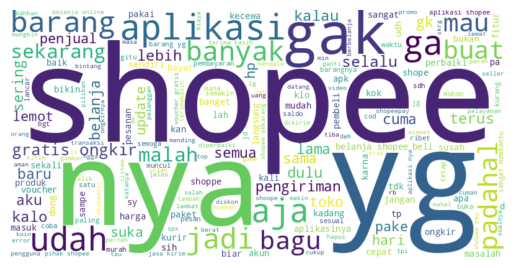

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = ' '.join(df['final_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## Visualisasi WordCloud

Pada tahap ini dilakukan visualisasi teks menggunakan WordCloud untuk melihat kata-kata yang paling sering muncul dalam dataset.

Data teks dari kolom `final_text` digabungkan menjadi satu string, kemudian divisualisasikan dalam bentuk WordCloud, di mana ukuran kata mencerminkan frekuensi kemunculannya dalam dataset.

Visualisasi ini membantu dalam memahami distribusi kata secara umum, serta memberikan gambaran awal mengenai kata-kata dominan yang dapat mempengaruhi hasil klasifikasi sentimen.

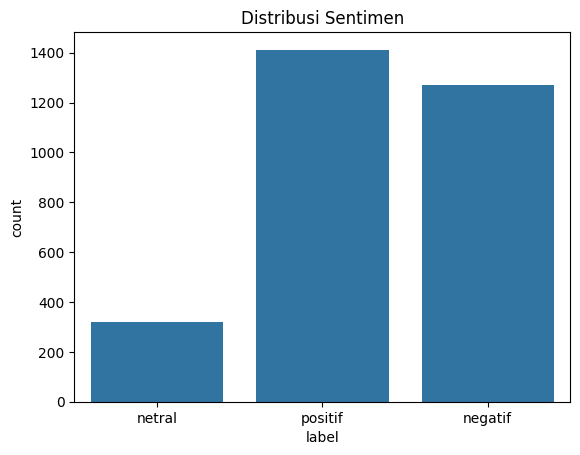

In [ ]:
import seaborn as sns

sns.countplot(x='label', data=df)
plt.title('Distribusi Sentimen')
plt.show()

## Visualisasi Distribusi Sentimen

Pada tahap ini dilakukan visualisasi distribusi jumlah data pada setiap kelas sentimen menggunakan `countplot` dari library seaborn.

Visualisasi ini bertujuan untuk memberikan gambaran yang lebih intuitif mengenai proporsi masing-masing kelas (negatif, netral, dan positif) dalam dataset.

Dengan melihat grafik ini, dapat diketahui apakah data memiliki distribusi yang seimbang atau tidak, yang nantinya akan berpengaruh terhadap performa model klasifikasi.

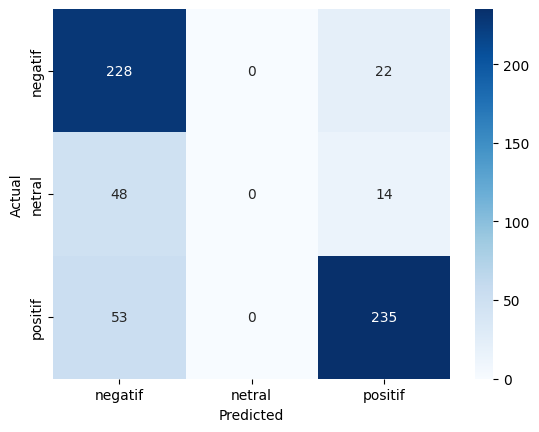

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_tfidf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negatif','netral','positif'],
            yticklabels=['negatif','netral','positif'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Confusion Matrix

Pada tahap ini digunakan Confusion Matrix untuk mengevaluasi performa model secara lebih detail.

Confusion Matrix menampilkan jumlah prediksi benar dan salah untuk setiap kelas dalam bentuk matriks.

- Baris menunjukkan label sebenarnya (actual)
- Kolom menunjukkan hasil prediksi model (predicted)

Visualisasi menggunakan heatmap memudahkan dalam melihat pola kesalahan model, seperti kelas mana yang sering salah diprediksi dan kecenderungan bias model terhadap kelas tertentu.

Analisis ini sangat penting untuk memahami kelemahan model yang tidak terlihat hanya dari nilai accuracy.